## **Session 3** - Variants of Gradient Descent
نکات کلیدی گرادیان نزولی پایه :

1. **Objective:** Minimize a cost function by iteratively moving in the direction of steepest descent.
2. **Update Rule:** $\theta = \theta - \alpha \nabla J(\theta) $, where $\theta$ are the parameters, $\alpha$ is the learning rate, and $\nabla J(\theta)$ is the gradient of the cost function.
3. **Challenges:**
    - Computationally expensive for large datasets
    - Sensitive to learning rate choice
    - Can be slow to converge in certain scenarios

---

we'll cover the following variants:

1. **Batch Gradient Descent**
2. **Stochastic Gradient Descent (SGD):** Uses a single training example per iteration.
3. **Mini-batch Gradient Descent:** Strikes a balance between basic GD and SGD.

---

هدف همه این الگوریتم‌ها یکی است: پیدا کردن مقادیری برای پارامترهای مدل که تابع هزینه را کمینه کنند. اما راهی که برای محاسبه‌ی گرادیان (شیب) و به‌روزرسانی وزن‌ها طی می‌کنند، کاملاً متفاوت است.

### Batch Gradient Descent
این روش یعنی تمام دیتا ممکن را به مدل بدهیم تا نحلیل کند و خودش را آپدیت کند. سپس دوباره تمام دیتا را به مدل بدهیم و روند را تکرار کنیم.

در این روش، برای یک بار به‌روزرسانی وزن‌ها، کل دیتاست را از شبکه عبور می‌دهیم، خطای کل را محاسبه کرده، گرادیان را نسبت به تمام داده‌ها می‌گیریم و سپس وزن را یک قدم به‌روز می‌کنیم.

---

#### Advantages
- همگرایی پایدار و دقیق: گرادیان دقیقاً بر اساس کل داده‌ها محاسبه می‌شود، بنابراین مسیر حرکت به سمت کمینه کاملاً صاف و بدون نوسان است.

- پیاده‌سازی ریاضی ساده‌تر: نیازی به نگرانی درباره نویز و نوسانات گرادیان نیست.

---

#### Disadvantages
- بسیار کند و سنگین: برای دیتاست‌های بزرگ (چند میلیون نمونه)، محاسبه گرادیان روی کل داده‌ها در هر قدم، از نظر محاسباتی غیرقابل تحمل است و حافظه را پر می‌کند.

- گیر کردن در نقطه کمینه محلی : چون هیچ نویزی در گرادیان وجود ندارد، اگر در یک نقطه‌ی سکون (فلات) یا کمینه محلی گرفتار شود، امکان فرار ندارد.

- غیر آنلاین نمی‌تواند روی داده‌های جدیدی که به‌مرور زمان اضافه می‌شوند، یاد بگیرد (یادگیری افزایشی غیرممکن است).



### Stochastic Gradient Descent (SGD)
در این روش، برای یک بار به‌روزرسانی وزن‌ها، فقط یک نمونه (یک دیتا پوینت) را به‌صورت تصادفی از دیتاست انتخاب کرده، گرادیان را فقط برای همان یک نمونه محاسبه کرده و وزن را به‌روز می‌کنیم.

---
#### Algorithm
1. Randomly shuffle the dataset
2. For each iteration:
    - Select a single example $(x_i, y_i)$ from the dataset
    - Compute the gradient of the loss function for this example
    - Update the parameters: $\theta = \theta - \alpha \nabla J(\theta; x_i, y_i)$

---

#### Mathematical Representation
for the dataset with $n$ examples, the update role for SDG is:
$$\theta = \theta - \alpha \nabla J_i(\theta)$$
where $J_i(\theta)$ is the loss for the $i$-th training example

---
#### Advantages
1. **Computational Efficiency:** Much faster per iteration, especially for large datasets.
2. **Online Learning:** Can handle streaming data or very large datasets that don't fit in memory.
3. **Escape Local Minima:** The noise in updates can help escape shallow local minima.
4. **Regularization Effect:** The noisy updates can have a regularizing effect, potentially improving generalization.

---

#### Challenge
1. **High Variance:** Updates can be noisy, leading to erratic convergence behavior.
2. **Sensitive to Feature Scaling:** Like basic GD, SGD is sensitive to the scaling of input features.
3. **Learning Rate Tuning:** Requires careful tuning of the learning rate for optimal performance.

---
#### Visualization

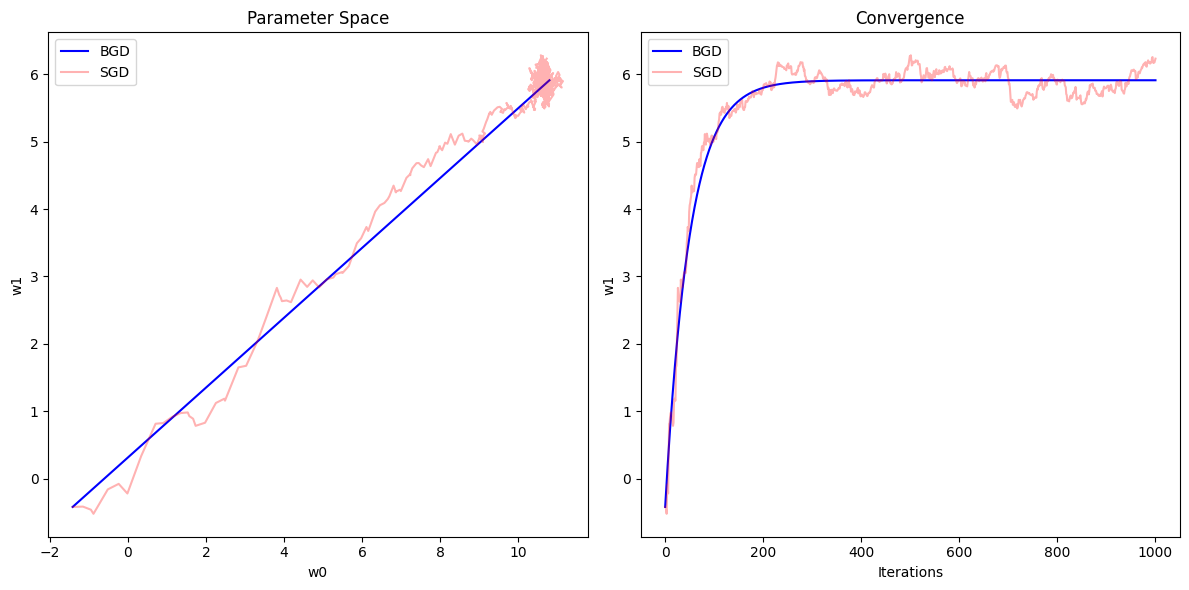

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = 2 * X + 1 + np.random.randn(100) * 2

# Normalize the data
X = (X - X.mean()) / X.std()

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]

# Initialize parameters
w = np.random.randn(2)

# Hyperparameters
learning_rate = 0.01
n_iterations = 1000

# Batch Gradient Descent
def bgd(X, y, w, learning_rate, n_iterations):
    w_history = [w.copy()]
    for _ in range(n_iterations):
        gradient = 2/len(y) * X.T.dot(X.dot(w) - y)
        w -= learning_rate * gradient
        w_history.append(w.copy())
    return np.array(w_history)

# Stochastic Gradient Descent
def sgd(X, y, w, learning_rate, n_iterations):
    w_history = [w.copy()]
    for _ in range(n_iterations):
        idx = np.random.randint(0, len(y))
        xi, yi = X[idx], y[idx]
        gradient = 2 * xi * (xi.dot(w) - yi)
        w -= learning_rate * gradient
        w_history.append(w.copy())
    return np.array(w_history)

# Run BGD and SGD
bgd_history = bgd(X, y, w.copy(), learning_rate, n_iterations)
sgd_history = sgd(X, y, w.copy(), learning_rate, n_iterations)

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.plot(bgd_history[:, 0], bgd_history[:, 1], 'b-', label='BGD')
plt.plot(sgd_history[:, 0], sgd_history[:, 1], 'r-', alpha=0.3, label='SGD')
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Parameter Space')
plt.legend()

plt.subplot(122)
plt.plot(np.arange(n_iterations+1), bgd_history[:, 1], 'b-', label='BGD')
plt.plot(np.arange(n_iterations+1), sgd_history[:, 1], 'r-', alpha=0.3, label='SGD')
plt.xlabel('Iterations')
plt.ylabel('w1')
plt.title('Convergence')
plt.legend()

plt.tight_layout()
plt.show()

### Mini-batch Gradient Descent
این روش، نقطه‌ی تعادل بین دو روش بالاست. در این روش، دیتاست را به دسته‌های کوچک با اندازه‌ی ثابت (مثلاً ۳۲، ۶۴، ۱۲۸ یا ۲۵۶ تایی) به نام بچ تقسیم می‌کنیم. وزن‌ها را پس از محاسبه‌ی گرادیان روی کل اعضای آن دسته  به‌روز می‌کنیم.

![alt](img_1.png)

---

#### Algorithm
1. Divide the training dataset into mini-batches of size m (where m is smaller than the full dataset size but larger than 1)
2. For each epoch, for each mini batch:
    - Compute the gradient of the loss function for the mini-batch
    - Update the parameters:  $\theta = \theta - \alpha \nabla J(\theta; X^{(i:i+m)}, Y^{(i:i+m)})$

---

#### Mathematical Representation
For a dataset with n examples divided into mini-batches of size m, the update rule is:
$$\theta = \theta - \alpha \nabla J(\theta; X^{(i:i+m)}, Y^{(i:i+m)})$$

---

#### Choosing Batch Size
اندازه بسته ها نباید خیلی کوچک یا خیلی بزرگ باشد

---
#### Advantages
- سَرعت بالا و استفاده از تسریع سخت‌افزاری: چون داده‌ها را به صورت ماتریسی و برداری به پردازنده (GPU) می‌دهد، از قابلیت‌های Vectorization به‌خوبی استفاده کرده و محاسبات را بسیار سریع‌تر از SGD می‌کند.

- کاهش نویز نسبت به SGD: گرادیان حاصل از میانگین چند نمونه، نویز کمتری دارد و مسیر همگرایی صاف‌تر و با ثبات‌تر است.

- فرار از کمینه محلی: همچنان به اندازه‌ی کافی نویز دارد که بتواند از نقاط سکون عبور کند.

- انعطاف‌پذیر: می‌توانید اندازه‌ی دسته را متناسب با قدرت حافظه‌ی GPU خود تنظیم کنید.

---

#### Disadvantages
- انتخاب اندازه‌ی دسته (Batch Size) یک هایپرپارامتر حیاتی است: اگر خیلی کوچک انتخاب شود (مثلاً ۱۶)، به SGD نزدیک می‌شود و نویز زیاد می‌شود. اگر خیلی بزرگ انتخاب شود (مثلاً ۵۱۲)، به Batch Gradient Descent نزدیک می‌شود و کند می‌گردد.

- نیاز به شافل کردن (Shuffling) داده‌ها: برای اینکه گرادیان واقعاً تصادفی باشد، باید قبل از هر Epoch، داده‌ها را کاملاً به هم بریزیم، وگرنه مدل دچار سوگیری (Bias) می‌شود.

![Compare](img_2.png)